<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangGraph(Part_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 2.7 MB/s eta 0:00:00


In [2]:
import operator

from IPython.display import Image
from google.colab import userdata
from langchain.agents import AgentState
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.runnables import RunnablePassthrough
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langgraph.types import Runnable
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pathlib import Path
from pydantic import SecretStr
from typing import Annotated, List, Literal, TypedDict

openai_api_key = SecretStr(userdata.get("OPENAI_API_KEY"))

def print_conversation(conversation: List[BaseMessage]):
    for message in conversation:
        message.pretty_print()

def display_graph(runnable: Runnable, output_png: Path) -> None:
    graph = runnable.get_graph()

    with output_png.open(mode = "wb") as file:
        file.write(graph.draw_mermaid_png())

    display(Image(output_png, format="png"))

In [3]:
@tool
def weather(city: str) -> str:
    """Return a (fake) current-weather report for a city."""
    data = {
        "sofia": "Sofia: 18 C, partly cloudy",
        "london": "London: 11 C, rainy",
        "tokyo": "Tokyo: 22 C, sunny"
    }

    return data.get(city.lower(), f"No data for {city}.")

@tool
def search(query: str) -> str:
    """Look up a term in the built-in mini-encyclopedia."""
    data = {
        "langgraph": "LangGraph is a library for building stateful, cyclic LLM apps",
        "react": "ReAct is a prompting pattern: Reason then Act, in a loop.",
        "dag": "A DAG is a directed acyclic graph - no cycles allowed."
    }
    return data.get(query.lower(), "(nothing found)")

SYSTEM_PROMPT = "You are a concise assistant. Use tools when useful."
TOOLS = [weather, search]

In [11]:
model = ChatOpenAI(model="gpt-5-nano", api_key = openai_api_key).bind_tools(TOOLS) # .bind_tools(TOOLS) защото създаваме агента от нулата

class CustomAgentState(AgentState):
    model_calls: int

def on_start(state: CustomAgentState):
    print("Our graph execution started!")

def on_end(state: CustomAgentState):
    print("Our graph execution just ended!")

def before_model_node(state: CustomAgentState):
    model_call_id = state.get('model_calls', 0) + 1
    print('='*20)
    print(f"Starting model call #{model_call_id}...")
    return { "model_calls": model_call_id }

def after_model_node(state: CustomAgentState):
    model_call_id = state.get('model_calls', 0)
    print(f"Model call #{model_call_id} completed!")
    print('='*20)

def model_node(state: CustomAgentState):
    response = model.invoke([SystemMessage(SYSTEM_PROMPT),*state["messages"]])
    return { "messages": [response] }

In [6]:
def has_pending_tool_calls(state: CustomAgentState) -> bool:
    messages = state.get("messages", [])

    if not messages:
        return False

    last_message = messages[-1]

    return isinstance(last_message, AIMessage) and last_message.tool_calls

In [20]:
graph_builder = StateGraph(CustomAgentState)
graph_builder.add_node("on_start", on_start) # симулираме middleware before_agent
graph_builder.add_node("on_end", on_end) # after_agent middleware

graph_builder.add_node("before_model", before_model_node) # before_model middleware
graph_builder.add_node("after_model", after_model_node) # after_model

graph_builder.add_node("model", model_node)
graph_builder.add_node("tools", ToolNode(TOOLS))

graph_builder.add_edge(START, "on_start")
graph_builder.add_edge("on_start", "before_model")
graph_builder.add_edge("before_model", "model")

graph_builder.add_edge("model", "after_model")

graph_builder.add_conditional_edges("after_model", lambda state: "tools" if has_pending_tool_calls(state) else "on_end", ["tools", "on_end"])
graph_builder.add_edge("tools", "before_model")
graph_builder.add_edge("on_end", END)


graph = graph_builder.compile()

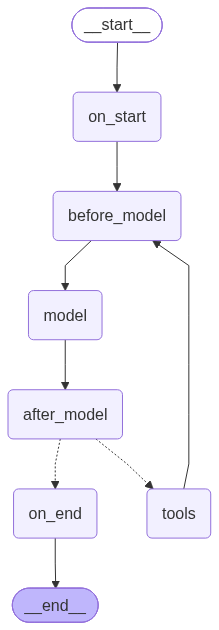

In [21]:
display_graph(graph, Path("/content/graph.png"))

In [22]:
final_state = graph.invoke(
    input = {
        "messages": [HumanMessage("What's the weather in Tokyo and what is LangGraph, briefly?")]
    }
)

Our graph execution started!
Starting model call #1...
Model call #1 completed!
Starting model call #2...
Model call #2 completed!
Our graph execution just ended!


In [23]:
print_conversation(final_state["messages"])

================================ Human Message =================================

What's the weather in Tokyo and what is LangGraph, briefly?
================================== Ai Message ==================================
Tool Calls:
  weather (call_vIFXjq8WEtDidOCN8yj4Gksc)
 Call ID: call_vIFXjq8WEtDidOCN8yj4Gksc
  Args:
    city: Tokyo
  search (call_11UyDZ4wU5DMys7jxQLaA0qb)
 Call ID: call_11UyDZ4wU5DMys7jxQLaA0qb
  Args:
    query: LangGraph
================================= Tool Message =================================
Name: weather

Tokyo: 22 C, sunny
================================= Tool Message =================================
Name: search

LangGraph is a library for building stateful, cyclic LLM apps
================================== Ai Message ==================================

- Tokyo weather: 22 C, sunny (fake current-weather report)
- LangGraph: a library for building stateful, cyclic LLM applications.


In [24]:
final_state

{'messages': [HumanMessage(content="What's the weather in Tokyo and what is LangGraph, briefly?", additional_kwargs={}, response_metadata={}, id='4cad82e1-e300-4338-8e40-d7e821588034'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 501, 'prompt_tokens': 183, 'total_tokens': 684, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EK0egrLZHikWQzV2219pNDekIBKkp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06732-e88a-7e82-9c0c-b4c2c993c0e9-0', tool_calls=[{'name': 'weather', 'args': {'city': 'Tokyo'}, 'id': 'call_vIFXjq8WEtDidOCN8yj4Gksc', 'type': 'tool_call'}, {'name': 'search', '